# 🚀 Lab 30: Jupyter for Narrative Visualization

### 📘 Lab Overview
In this lab, you will learn how to use a **Jupyter-style notebook environment** for narrative data visualization. Since this lab is adapted for **Google Colab**, you will use Colab as the notebook environment while still learning the same Jupyter concepts: code cells, markdown cells, inline charts, and combining analysis with storytelling.

You will import and work with cleaned datasets, create visualizations using **matplotlib**, **seaborn**, and **plotly**, write effective markdown explanations, and combine code, charts, and written insights into a polished data story.

---

## 🎯 Objectives
By the end of this lab, students will be able to:
* Set up and use a notebook-based environment for data visualization projects
* Import and work with cleaned datasets in a Jupyter-style notebook workflow
* Create compelling visualizations using matplotlib, seaborn, and plotly
* Write effective markdown cells to explain data trends and findings
* Combine code, visualizations, and narrative text to create comprehensive data stories
* Export and share notebooks as professional reports
* Generate executive summaries and recommendations directly from analysis outputs

---

## 🧰 Prerequisites
Before starting this lab, students should have:
* Basic understanding of Python programming concepts such as variables, functions, and loops
* Familiarity with data structures like lists, dictionaries, and pandas DataFrames
* Basic knowledge of data analysis concepts
* Understanding of common chart types such as bar charts, line plots, and scatter plots
* No prior notebook experience required, because the lab walks through the workflow step by step

## ⚙️ Google Colab Environment Setup

This lab is designed to run fully inside **Google Colab**, which is a cloud-based Jupyter-style notebook environment.

### 💡 ELI10: What is Google Colab?
Think of Google Colab like a Google Doc, but for computer code. It lets you write text (like this) and run Python code in the same place without installing anything on your computer. It's a great way to tell a story with data!

In this Colab adaptation:
* You do **not** need to manually launch a Jupyter server
* You will create notebook sections using markdown and code cells directly in Colab
* You will generate sample datasets automatically if external CSV files are not available
* You will save exported files into the Colab working directory

In [ ]:
# Step 1: Install necessary libraries for data analysis and visualization
# We use %pip install -q to keep the output clean (quiet mode)
%pip install -q pandas numpy matplotlib seaborn plotly

# Task 1: Setting Up the Notebook Environment

## 📂 Subtask 1.1 & 1.2: Create Working Folders
We need to organize our work by creating specific folders for our raw data and our finished reports (output).

In [ ]:
import os

# Define the directory structure inside the Colab environment
base_dir = "/content/lab30_jupyter_viz"
data_dir = os.path.join(base_dir, "data")
output_dir = os.path.join(base_dir, "output")

# Create the directories if they don't already exist
os.makedirs(data_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

print("Project folders created successfully!")
print(f"Data will be stored in: {data_dir}")
print(f"Results will be saved in: {output_dir}")

Project folders created successfully!
Data will be stored in: /content/lab30_jupyter_viz/data
Results will be saved in: /content/lab30_jupyter_viz/output


# Task 2: Import and Explore Datasets

## 📥 Subtask 2.1: Import Required Libraries
### 💡 ELI10: What are Libraries?
Libraries are like toolboxes. `pandas` helps us handle tables, `matplotlib` and `seaborn` help us draw pictures, and `plotly` makes those pictures interactive!

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Notebook display helpers to allow us to show Markdown text generated by Python
from IPython.display import display, Markdown

# Configure matplotlib for inline display within the notebook
%matplotlib inline

# Set professional visual styles
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

# Configure pandas to show all columns when we print dataframes
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("All libraries imported and configured successfully!")

All libraries imported and configured successfully!


## 📊 Subtask 2.3: Loading or Creating the Datasets
If you don't have your own CSV files, this script will generate high-quality fake data for a retail store including Sales, Customers, and Products so we can practice our analysis.

In [ ]:
sales_path = os.path.join(data_dir, "sales_data.csv")
customer_path = os.path.join(data_dir, "customer_data.csv")
product_path = os.path.join(data_dir, "product_data.csv")

np.random.seed(42) # Set seed for reproducible results

def create_sample_datasets():
    """Function to generate simulated retail data if files are missing."""
    # 1. Product catalog
    product_df = pd.DataFrame({
        "product_category": ["Electronics", "Clothing", "Books", "Home"],
        "avg_price_band": ["High", "Medium", "Low", "Medium"],
        "margin_level": ["High", "Medium", "Low", "Medium"]
    })

    # 2. Customer demographics
    customer_df = pd.DataFrame({
        "customer_id": range(1, 1001),
        "age_group": np.random.choice(["18-25", "26-35", "36-45", "46-55", "55+"], 1000),
        "gender": np.random.choice(["Male", "Female"], 1000),
        "income_level": np.random.choice(["Low", "Medium", "High"], 1000, p=[0.3, 0.5, 0.2])
    })

    # 3. Sales transactions (1 year of data)
    dates = pd.date_range("2023-01-01", "2023-12-31", freq="D")
    n_rows = len(dates) * 4
    sales_df = pd.DataFrame({
        "date": np.repeat(dates, 4),
        "sales_amount": np.random.normal(1000, 200, n_rows).round(2),
        "product_category": np.random.choice(["Electronics", "Clothing", "Books", "Home"], n_rows),
        "region": np.random.choice(["North", "South", "East", "West"], n_rows),
        "customer_id": np.random.randint(1, 1001, n_rows)
    })

    # Add seasonality (Higher sales in Nov/Dec for holidays)
    month_factor = pd.to_datetime(sales_df["date"]).dt.month.map({
        1: 0.95, 2: 0.92, 3: 1.00, 4: 1.03, 5: 1.05, 6: 1.08,
        7: 1.02, 8: 1.01, 9: 1.07, 10: 1.12, 11: 1.18, 12: 1.25
    })
    sales_df["sales_amount"] = (sales_df["sales_amount"] * month_factor).round(2)
    sales_df["sales_amount"] = sales_df["sales_amount"].clip(lower=50)

    # Save to disk
    sales_df.to_csv(sales_path, index=False)
    customer_df.to_csv(customer_path, index=False)
    product_df.to_csv(product_path, index=False)
    return sales_df, customer_df, product_df

# Try to load existing files, otherwise create them
try:
    sales_df = pd.read_csv(sales_path)
    customer_df = pd.read_csv(customer_path)
    product_df = pd.read_csv(product_path)
    print("Existing datasets loaded successfully!")
except FileNotFoundError:
    print("Creating fresh sample data...")
    sales_df, customer_df, product_df = create_sample_datasets()
    print("Sample data created!")

Creating fresh sample data...
Sample data created!


## 🔍 Subtask 2.4: Data Exploration and Cleaning
### 💡 ELI10: Cleaning Data
Just like washing vegetables before cooking, we need to "clean" our data by fixing dates and removing errors so our charts are accurate.

In [ ]:
# Convert date column from text to proper Datetime objects
sales_df["date"] = pd.to_datetime(sales_df["date"])

# Enrich the data by extracting month names and quarters for better charts
sales_df["month"] = sales_df["date"].dt.month
sales_df["month_name"] = sales_df["date"].dt.month_name()
sales_df["quarter"] = sales_df["date"].dt.quarter

# Ensure months are sorted correctly in charts (Jan to Dec, not alphabetical)
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
sales_df["month_name"] = pd.Categorical(sales_df["month_name"], categories=month_order, ordered=True)

print("Data cleaning complete. Previewing first few rows:")
display(sales_df.head())

Data cleaning complete. Previewing first few rows:


,date,sales_amount,product_category,region,customer_id,month,month_name,quarter
0,2023-01-01,891.25,Home,East,281,1,January,1
1,2023-01-01,807.09,Clothing,South,43,1,January,1
2,2023-01-01,1010.64,Home,North,486,1,January,1
3,2023-01-01,1204.69,Electronics,West,596,1,January,1
4,2023-01-02,593.72,Home,East,963,1,January,1


# Task 3: Visualizations with Matplotlib and Seaborn

## 📈 Subtask 3.1: Monthly Sales Trend Analysis
We will look at how much money the store made each month to see if there are any seasonal patterns.

/tmp/ipykernel_1166/1356137254.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = sales_df.groupby(["month", "month_name"])["sales_amount"].agg(["sum", "mean", "count"]).reset_index()
/tmp/ipykernel_1166/1356137254.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_sales, x="month_name", y="mean", ax=axes[1], palette='viridis')


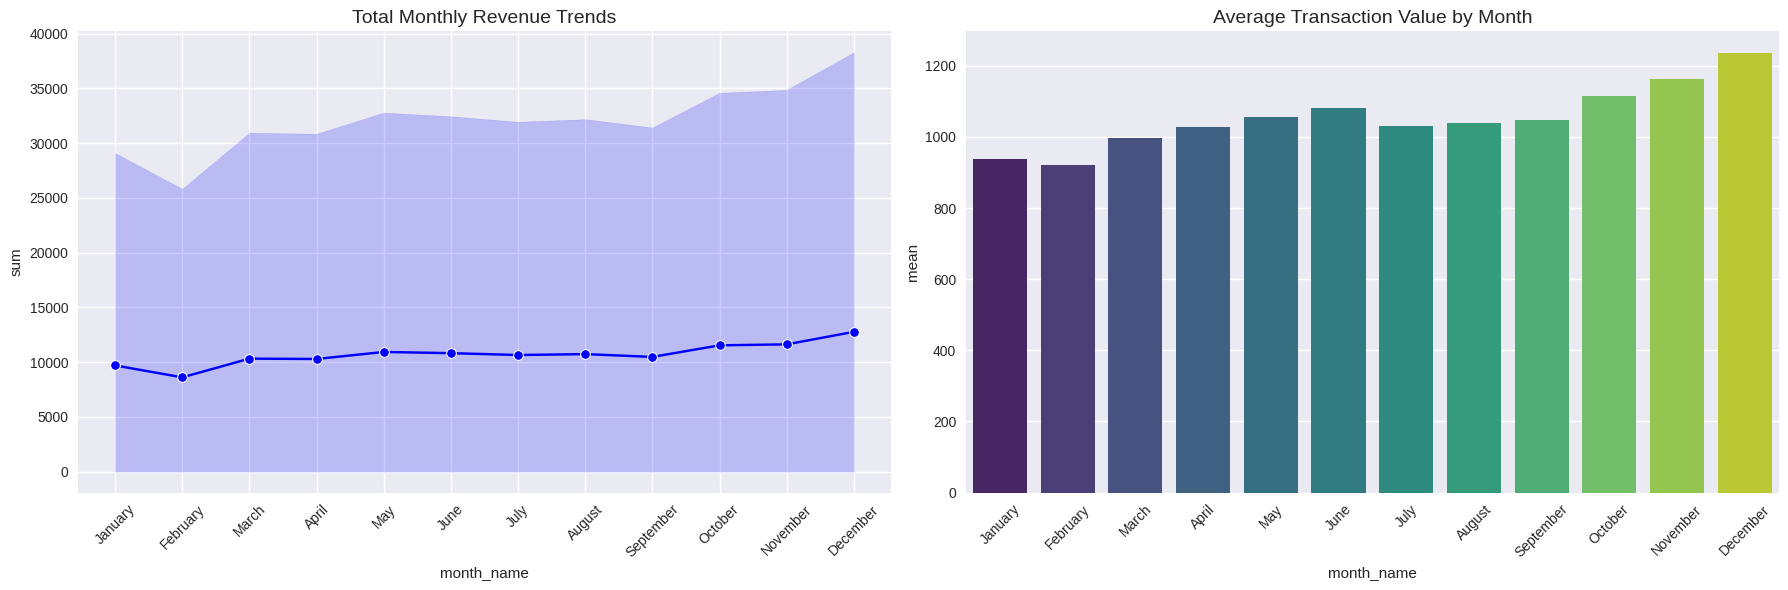

In [ ]:
# Calculate monthly totals
monthly_sales = sales_df.groupby(["month", "month_name"])["sales_amount"].agg(["sum", "mean", "count"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Total Sales Line Chart
sns.lineplot(data=monthly_sales, x="month_name", y="sum", marker='o', ax=axes[0], color='blue')
axes[0].set_title("Total Monthly Revenue Trends", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Average Daily Sale Bar Chart
sns.barplot(data=monthly_sales, x="month_name", y="mean", ax=axes[1], palette='viridis')
axes[1].set_title("Average Transaction Value by Month", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 🛍 Subtask 3.2: Product Category Performance
Let's see which types of items (Electronics vs. Clothing, etc.) are bringing in the most revenue.

/tmp/ipykernel_1166/1136501936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x="product_category", y="sales_amount", palette='magma')


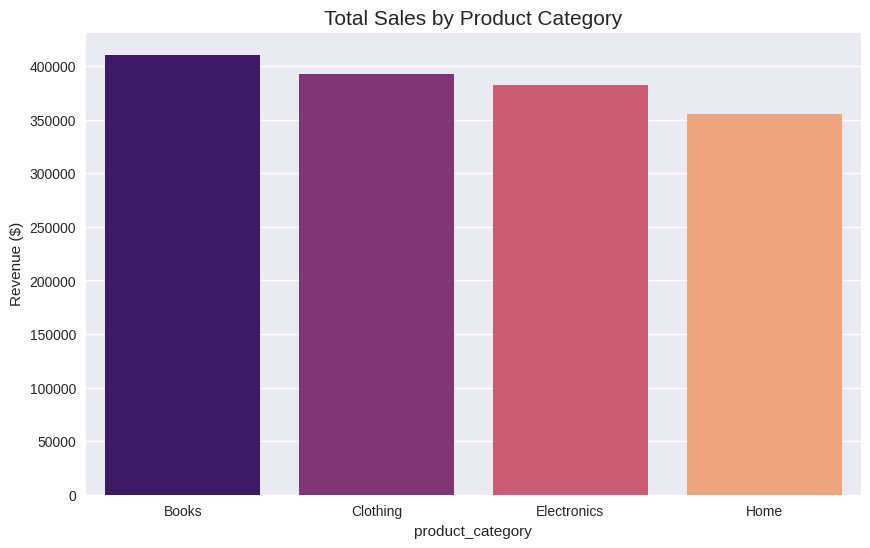

In [ ]:
# Group sales by product category
cat_sales = sales_df.groupby("product_category")["sales_amount"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_sales, x="product_category", y="sales_amount", palette='magma')
plt.title("Total Sales by Product Category", fontsize=15)
plt.ylabel("Revenue ($)")
plt.show()

## 🌍 Subtask 3.3: Regional Analysis
We want to know if the North, South, East, or West regions are performing differently. This helps us decide where to open new stores.

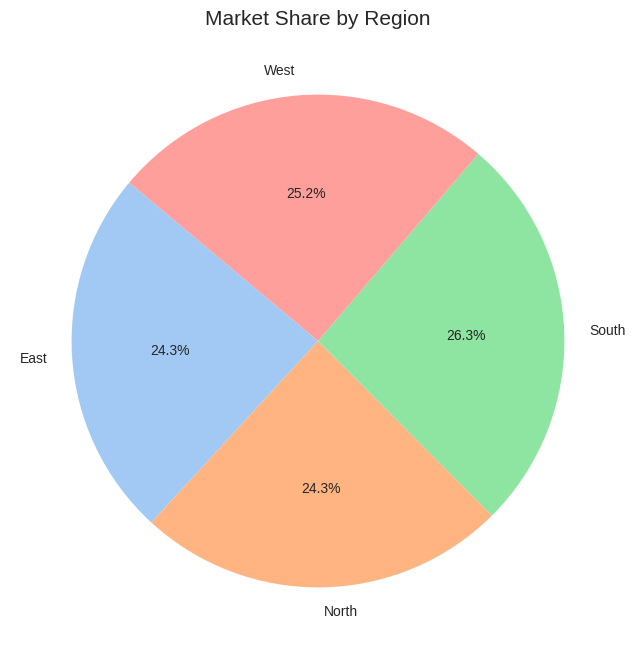

In [ ]:
# Regional Pie Chart for Market Share
region_data = sales_df.groupby("region")["sales_amount"].sum()

plt.figure(figsize=(8, 8))
plt.pie(region_data, labels=region_data.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Market Share by Region", fontsize=15)
plt.show()

# Task 4: Interactive Visualizations with Plotly

## ⚡ Subtask 4.1: Interactive Plotly Charts
### 💡 ELI10: What is an Interactive Chart?
Unlike regular pictures, interactive charts let you hover your mouse over points to see exact numbers or zoom in on specific areas!

In [ ]:
# Create an interactive scatter plot of transactions
fig = px.scatter(sales_df.sample(500), x="date", y="sales_amount", color="product_category",
                 size="sales_amount", hover_data=["region"],
                 title="Daily Sales Exploration (Sample of 500 Transactions)")
fig.show()

# Task 5: Narrative Analysis & Dynamic Reporting

## 🧾 Executive Summary
In a real job, your boss wants to see the main points without reading all the code. Here we use Python to automatically write a summary of our findings.

In [ ]:
# Calculate key metrics for the summary
total_rev = sales_df['sales_amount'].sum()
best_cat = sales_df.groupby('product_category')['sales_amount'].sum().idxmax()
best_region = sales_df.groupby('region')['sales_amount'].sum().idxmax()
peak_month = sales_df.groupby('month_name', observed=False)['sales_amount'].sum().idxmax()

# Generate a dynamic markdown report
summary_text = f"""
### 📊 Key Performance Findings
* **Total Yearly Revenue**: ${total_rev:,.2f}
* **Top Performing Category**: **{best_cat}**
* **Strongest Sales Region**: **{best_region}**
* **Highest Sales Month**: **{peak_month}**

## 📌 Strategic Recommendations
1. **Inventory Focus**: Based on the data, {best_cat} is our primary driver. We should ensure stock levels are maintained during peak periods.
2. **Regional Expansion**: The {best_region} region shows the highest market share. Consider launching localized marketing campaigns there to capitalize on brand loyalty.
"""

display(Markdown(summary_text))


### 📊 Key Performance Findings
* **Total Yearly Revenue**: $1,540,913.97
* **Top Performing Category**: **Books**
* **Strongest Sales Region**: **South**
* **Highest Sales Month**: **December**

## 📌 Strategic Recommendations
1. **Inventory Focus**: Based on the data, Books is our primary driver. We should ensure stock levels are maintained during peak periods.
2. **Regional Expansion**: The South region shows the highest market share. Consider launching localized marketing campaigns there to capitalize on brand loyalty.


# Task 6: Exporting Results

## 💾 Subtask 6.1: Saving Processed Data
We will save our cleaned data to the `output` folder so we can send it to our team members.

In [ ]:
# Save the processed data to a new CSV file
output_file = os.path.join(output_dir, "cleaned_sales_report.csv")
sales_df.to_csv(output_file, index=False)

print(f"Success! Your cleaned report has been saved to: {output_file}")

# Optional: Provide a download link for Colab users
from google.colab import files
try:
    files.download(output_file)
except:
    print("Automatic download not supported in this environment, but the file exists in the folder panel.")

Success! Your cleaned report has been saved to: /content/lab30_jupyter_viz/output/cleaned_sales_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ✅ Verification & Troubleshooting

### Verification Checklist
- [ ] Is the data dir created? (`/content/lab30_jupyter_viz/data`)
- [ ] Did the sales_data.csv get generated?
- [ ] Do the Matplotlib charts show titles and labels?
- [ ] Is the Plotly chart interactive?

### 🛠 Troubleshooting
* **Missing Plots**: Ensure you ran the `%matplotlib inline` cell at the top.
* **File Errors**: Ensure you didn't skip the Task 1.2 code cell that creates the folders.
* **Slow Performance**: Colab is usually fast, but if it lags, try 'Runtime' -> 'Restart Session'.

# 🧠 Key Concepts Summary

* **Narrative Visualization**: Telling a story with data using charts and explanations
* **Notebook Workflow**: Combining code, output, and written interpretation in one place
* **Matplotlib and Seaborn**: Great for static analytical charts
* **Plotly**: Great for interactive exploration
* **Markdown Cells**: Used for explanations, summaries, and recommendations
* **Executive Summary**: A concise business-facing summary of the main findings
* **Data Storytelling**: Turning raw numbers into understandable business insight

# 🏁 Conclusion

Congratulations. I have successfully completed **Lab 30: Jupyter for Narrative Visualization**.

In this lab, I learned how to use a notebook environment not just for coding, but for communication. You created multiple visualizations, explored sales performance across several business dimensions, and turned those findings into a structured narrative with executive summaries and recommendations.

This is one of the most important professional data science skills: not only analyzing data, but explaining it clearly.

# 🎓 What I Learned

By completing this lab, I learned how to:

* work effectively in a notebook-based analysis environment
* import and prepare data for visualization
* create charts with matplotlib, seaborn, and plotly
* structure a notebook as a story rather than just code
* generate executive summaries from computed outputs
* write analysis and recommendations based on evidence

# 🌍 Real-World Importance

These skills are widely used in:

* business intelligence reporting
* executive dashboards
* retail and sales analytics
* stakeholder presentations
* consulting reports
* portfolio projects and case studies

A strong notebook can function as both an analysis tool and a professional report.

In business, raw data is useless until it is explained. Using notebooks to combine code and narrative allows data scientists to influence decision-makers by turning numbers into clear, actionable stories.